<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/2_Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arabic Readability Classification on BAREC

## Research-grounded comparison of three AraBERTv0.2 objectives

This notebook compares three training objectives on the same four-level BAREC data splits:

1. Weighted Cross-Entropy classification.
2. Rank-consistent CORAL ordinal classification.
3. Mean Squared Error (MSE) ordinal regression.

The checkpoint is `aubmindlab/bert-base-arabertv02`; therefore, the technically correct model name used throughout this notebook is **AraBERTv0.2**. The test split is reserved for a single final evaluation after selecting the model with validation QWK.


# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [1]:
# Install all dependencies required by the complete notebook.
!pip -q install -U datasets pandas transformers accelerate scikit-learn seaborn coral-pytorch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.


In [2]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

README.md:   0%|          | 0.00/6.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/dev-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.37MB            

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/54845 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/7310 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7286 [00:00<?, ? examples/s]

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='str')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [3]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [4]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [5]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")

# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [6]:
filtered_full_df.isnull().sum()

Word                    0
Word_Count              0
Domain                  0
Text_Class              0
Readability_Level_19    0
Readability_Level_5     0
dtype: int64

**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [7]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [8]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0
Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level and 5-level readability classes to understand whether the dataset is balanced or imbalanced.

In [9]:
# Distribution for Readability Level 19
level_19_stats = (
    filtered_full_df["Readability_Level_19"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

level_19_stats["Percentage"] = (
    level_19_stats["Count"] / len(filtered_full_df) * 100
).round(2)

print("=== Readability Level 19 ===")
display(level_19_stats)


# Distribution for Readability Level 5
level_5_stats = (
    filtered_full_df["Readability_Level_5"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

level_5_stats["Percentage"] = (
    level_5_stats["Count"] / len(filtered_full_df) * 100
).round(2)

print("=== Readability Level 5 ===")
display(level_5_stats)

=== Readability Level 19 ===


,Count,Percentage
Readability_Level_19,,
1,409,0.59
2,437,0.63
3,1462,2.11
4,751,1.08
5,3443,4.96
6,1534,2.21
7,5438,7.83
8,5683,8.18
9,2023,2.91


=== Readability Level 5 ===


,Count,Percentage
Readability_Level_5,,
1,13474,19.40
2,22383,32.23
3,18510,26.66
4,13234,19.06
5,1840,2.65


In [10]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

Readability_Level_19
1       409
2       437
3      1462
4       751
5      3443
6      1534
7      5438
8      5683
9      2023
10     9763
11     4914
12    14471
13     4039
14    10687
15     2547
16     1141
17      480
18      103
19      116
Name: count, dtype: int64

In [11]:
filtered_full_df["Readability_Level_5"].value_counts().sort_index()

Readability_Level_5
1    13474
2    22383
3    18510
4    13234
5     1840
Name: count, dtype: int64

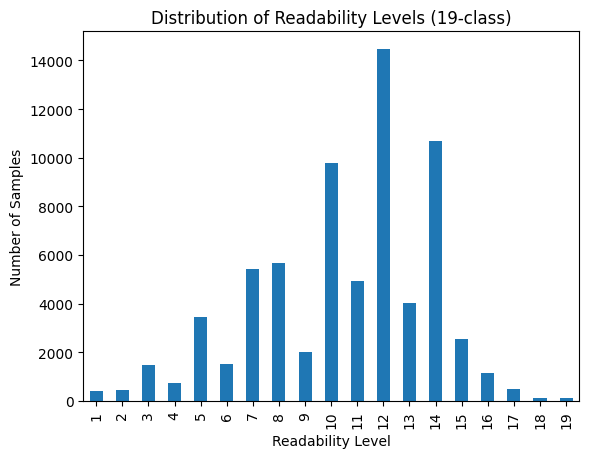

In [12]:
import matplotlib.pyplot as plt

full_df["Readability_Level_19"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

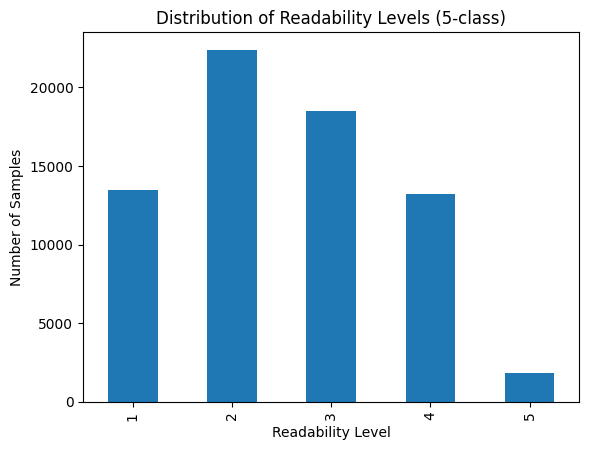

In [13]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (5-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 and 5 readability levels. Some classes contain a significantly higher number of samples, while higher levels have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.

##Handling Class Label Inbalance

### Step 1: Merge Readability Classes 4 and 5

The original `Readability_Level_5` contains five readability classes.

To reduce the class imbalance, Classes 4 and 5 will be merged into a single class. All samples originally labeled as Class 5 will be relabeled as Class 4.

As a result, the dataset will contain four readability classes: 1, 2, 3, and 4.

The original Class 5 label will no longer exist in the dataset.

In [14]:
# Create separate copies of the original BAREC splits
train_4 = filtered_train_df.copy()
val_4 = filtered_dev_df.copy()
test_4 = filtered_test_df.copy()

# Merge original Class 5 into Class 4 within each split
train_4["Readability_Level_5"] = train_4["Readability_Level_5"].replace(5, 4)
val_4["Readability_Level_5"] = val_4["Readability_Level_5"].replace(5, 4)
test_4["Readability_Level_5"] = test_4["Readability_Level_5"].replace(5, 4)

# Rename the target column
train_4 = train_4.rename(columns={"Readability_Level_5": "Readability_Level_4"})
val_4 = val_4.rename(columns={"Readability_Level_5": "Readability_Level_4"})
test_4 = test_4.rename(columns={"Readability_Level_5": "Readability_Level_4"})

# Display the original BAREC split sizes
print("=== Four-Class Dataset Sizes ===")
print(f"Train: {len(train_4)}")
print(f"Validation: {len(val_4)}")
print(f"Test: {len(test_4)}")

=== Four-Class Dataset Sizes ===
Train: 54845
Validation: 7310
Test: 7286


### Step 2: Verify the Four-Class Class Distribution

The class distribution is examined separately for the training, validation, and test sets after merging Classes 4 and 5. This step verifies that the four-class target contains only Classes 1, 2, 3, and 4.

In [15]:
# Check the four-class distribution in each split

print("=== Train Class Distribution ===")
print(train_4["Readability_Level_4"].value_counts().sort_index())

print("\n=== Validation Class Distribution ===")
print(val_4["Readability_Level_4"].value_counts().sort_index())

print("\n=== Test Class Distribution ===")
print(test_4["Readability_Level_4"].value_counts().sort_index())

=== Train Class Distribution ===
Readability_Level_4
1    10396
2    17908
3    14570
4    11971
Name: count, dtype: int64

=== Validation Class Distribution ===
Readability_Level_4
1    1679
2    2270
3    1840
4    1521
Name: count, dtype: int64

=== Test Class Distribution ===
Readability_Level_4
1    1399
2    2205
3    2100
4    1582
Name: count, dtype: int64


### Step 3: Calculate Class Percentages

The percentage of each readability class is calculated for the training, validation, and test sets. This provides a clearer view of the class distribution and the remaining class imbalance after merging Classes 4 and 5.

In [16]:
# Calculate class percentages for each split

for name, df in [
    ("Train", train_4),
    ("Validation", val_4),
    ("Test", test_4)
]:
    percentages = (
        df["Readability_Level_4"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print(f"\n=== {name} Class Percentages ===")
    print(percentages.round(2))


=== Train Class Percentages ===
Readability_Level_4
1    18.96
2    32.65
3    26.57
4    21.83
Name: proportion, dtype: float64

=== Validation Class Percentages ===
Readability_Level_4
1    22.97
2    31.05
3    25.17
4    20.81
Name: proportion, dtype: float64

=== Test Class Percentages ===
Readability_Level_4
1    19.20
2    30.26
3    28.82
4    21.71
Name: proportion, dtype: float64


# Deep Learning Experiment

## Experimental protocol

All models use the official BAREC train/dev/test partitions and the same four-class mapping. Model development and checkpoint selection use only the training and validation partitions. The test partition is evaluated once after the validation winner is fixed. This prevents test-set information from influencing model selection.

The three objectives isolate the effect of the output formulation while holding the encoder, tokenization, data partitions, maximum sequence length, optimizer schedule, and evaluation metrics constant.


In [17]:
import inspect
import json
import math
import os
import random
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)
from transformers import (
    AutoConfig,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from coral_pytorch.layers import CoralLayer
from coral_pytorch.losses import coral_loss

warnings.filterwarnings("ignore", category=FutureWarning)

MODEL_NAME = "aubmindlab/bert-base-arabertv02"
TEXT_COLUMN = "Word"
LABEL_COLUMN = "Readability_Level_4"
NUM_LABELS = 4
MAX_LENGTH = 128
SEED = 42
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRADIENT_ACCUMULATION_STEPS = 2
NUM_EPOCHS = 3
WEIGHT_DECAY = 0.01
WARMUP_FRACTION = 0.10

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if not torch.cuda.is_available():
    print("Warning: transformer fine-tuning on CPU will be very slow. Select a GPU runtime in Colab.")


Device: cuda


## Parameter justification

| Choice | Value | Academic or empirical basis |
|---|---:|---|
| Encoder | `bert-base-arabertv02` | Arabic pretrained transformer introduced by Antoun et al. [1]. The exact checkpoint name identifies AraBERTv0.2. |
| Learning rate | `2e-5` | One of the BERT fine-tuning rates evaluated by Devlin et al. [2] and used in the BAREC STBW system [7]. |
| Train batch size | `16` | Included in the BERT fine-tuning grid [2]. Gradient accumulation of 2 gives an effective batch size of 32 while fitting limited GPU memory. |
| Validation batch size | `32` | Inference does not store gradients; a larger batch reduces evaluation time when memory permits. It does not change learned parameters. |
| Epochs | `3` | A short BERT fine-tuning schedule consistent with Devlin et al. [2]. The best checkpoint is selected by validation QWK rather than the final epoch. |
| Weight decay | `0.01` | AdamW regularization value reported in the BERT training configuration [2]. |
| Warm-up | `10%` of update steps | Used by the BAREC STBW training procedure [7]; it stabilizes early optimization. |
| Dropout | `0.1` | Standard BERT hidden-state dropout [2]. |
| Maximum length | `128` tokens | Verified below against this project's training-token distribution. This is a data-dependent engineering choice, not a claimed universal optimum. |
| Random seed | `42` | Fixed solely for reproducibility; it is not claimed to be performance-optimal. |
| CORAL threshold | `0.5` | Converts each sigmoid boundary probability into a binary ordinal decision, following the CORAL formulation [4]. |
| Selection metric | Validation QWK | BAREC labels are ordered; quadratic weighting penalizes distant mistakes more strongly and is the official shared-task metric [3]. |

The numerical settings are fixed before test evaluation. A future hyperparameter study should tune them on the validation split only.


## 1. Final data preparation

Labels are converted from human-readable levels `1–4` to zero-based indices `0–3`, as required by PyTorch losses. No class is removed, and the official split identities are preserved.


In [18]:
def prepare_dl_split(df):
    prepared = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna().copy()
    prepared[TEXT_COLUMN] = prepared[TEXT_COLUMN].astype(str).str.strip()
    prepared = prepared[prepared[TEXT_COLUMN].str.len() > 0].reset_index(drop=True)
    prepared["labels"] = prepared[LABEL_COLUMN].astype(int) - 1
    if not prepared["labels"].between(0, NUM_LABELS - 1).all():
        raise ValueError("Labels must map to the zero-based range 0..3.")
    return prepared[[TEXT_COLUMN, "labels"]]

train_dl = prepare_dl_split(train_4)
val_dl = prepare_dl_split(val_4)
test_dl = prepare_dl_split(test_4)

print("Train:", train_dl.shape)
print("Validation:", val_dl.shape)
print("Test:", test_dl.shape)
display(train_dl.head())


Train: (54845, 2)
Validation: (7310, 2)
Test: (7286, 2)


,Word,labels
0,مجلة كل الأولاد وكل البنات,0
1,ماجد,0
2,الأربعاء 21 يناير 1987,1
3,الموافق 21 جمادى الأول 1407ه,0
4,السنة الثامنة,0


## 2. Tokenization and sequence-length verification

The tokenizer must match the pretrained checkpoint. Length statistics are computed from the training split only. The reported percentage above 128 tokens quantifies the truncation introduced by `MAX_LENGTH=128` and allows this value to be defended empirically.


In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_token_ids = tokenizer(
    train_dl[TEXT_COLUMN].tolist(),
    add_special_tokens=True,
    truncation=False,
)["input_ids"]
train_lengths = np.asarray([len(ids) for ids in train_token_ids])

length_summary = pd.Series(train_lengths).describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
).to_frame("tokens")
display(length_summary)
print(f"Training examples longer than {MAX_LENGTH}: {(train_lengths > MAX_LENGTH).mean():.2%}")

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        max_length=MAX_LENGTH,
    )

def to_tokenized_dataset(df):
    dataset = Dataset.from_pandas(df, preserve_index=False)
    return dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=[TEXT_COLUMN],
        desc="Tokenizing",
    )

train_ds = to_tokenized_dataset(train_dl)
val_ds = to_tokenized_dataset(val_dl)
test_ds = to_tokenized_dataset(test_dl)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

,tokens
count,54845.000000
mean,19.439876
std,14.044356
min,3.000000
50%,16.000000
90%,38.000000
95%,46.000000
99%,66.000000
max,227.000000


Training examples longer than 128: 0.03%


Tokenizing:   0%|          | 0/54845 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/7310 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/7286 [00:00<?, ? examples/s]

## 3. Evaluation metrics

Accuracy and Macro-F1 measure exact classification performance. QWK, MAE, and RMSE use the ordering of readability levels. RMSE penalizes large level errors more strongly than MAE. `within_one` reports the proportion of predictions no more than one level away from the reference.


In [20]:
def ordinal_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "within_one": np.mean(np.abs(y_true - y_pred) <= 1),
    }

def unpack_logits(predictions):
    return predictions[0] if isinstance(predictions, tuple) else predictions

def compute_cross_entropy_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(unpack_logits(logits), axis=-1)
    return ordinal_metrics(labels, predictions)

def coral_logits_to_labels(logits):
    probabilities = torch.sigmoid(torch.as_tensor(logits)).cpu().numpy()
    return (probabilities > 0.5).sum(axis=1).astype(int)

def compute_coral_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = coral_logits_to_labels(unpack_logits(logits))
    return ordinal_metrics(labels, predictions)

def regression_outputs_to_labels(outputs):
    raw_scores = np.asarray(outputs).reshape(-1)
    return np.clip(np.rint(raw_scores), 0, NUM_LABELS - 1).astype(int)

def compute_mse_metrics(eval_pred):
    outputs, labels = eval_pred
    raw_scores = np.asarray(unpack_logits(outputs)).reshape(-1)
    predictions = regression_outputs_to_labels(raw_scores)
    metrics = ordinal_metrics(labels, predictions)
    metrics["raw_mae"] = mean_absolute_error(labels, raw_scores)
    metrics["raw_rmse"] = np.sqrt(mean_squared_error(labels, raw_scores))
    return metrics


## 4. Shared training configuration

All three models receive the same update budget and checkpoint-selection rule. `save_total_limit=1` retains only the best checkpoint to reduce storage. Mixed precision is enabled only when a CUDA GPU supports it.


In [21]:
updates_per_epoch = math.ceil(
    len(train_ds) / (TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
)
total_update_steps = updates_per_epoch * NUM_EPOCHS
warmup_steps = round(WARMUP_FRACTION * total_update_steps)

def make_training_args(output_dir):
    parameters = inspect.signature(TrainingArguments.__init__).parameters
    kwargs = dict(
        output_dir=output_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=warmup_steps,
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="qwk",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=SEED,
        data_seed=SEED,
    )
    if "eval_strategy" in parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"
    return TrainingArguments(**kwargs)

print("Updates per epoch:", updates_per_epoch)
print("Total update steps:", total_update_steps)
print("Warm-up steps:", warmup_steps)


Updates per epoch: 1714
Total update steps: 5142
Warm-up steps: 514


## 5. Model 1 — AraBERTv0.2 with Weighted Cross-Entropy

Cross-entropy is the standard objective for mutually exclusive text classes and was evaluated with AraBERT in the original BAREC study [5]. It is used here as a **nominal classification comparator**, not described as the official BAREC baseline. Inverse-frequency weights are computed from the training split only to reduce the dominance of frequent classes. This weighting is a project adaptation to the observed imbalance; it is not claimed to reproduce the unweighted BAREC configuration.


In [22]:
class_counts = np.bincount(train_dl["labels"], minlength=NUM_LABELS)
class_weights = len(train_dl) / (NUM_LABELS * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

display(pd.DataFrame({
    "level": np.arange(1, NUM_LABELS + 1),
    "training_count": class_counts,
    "cross_entropy_weight": class_weights,
}))

class WeightedCrossEntropyTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_function = nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(outputs.logits.device)
        )
        loss = loss_function(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

set_seed(SEED)
cross_entropy_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

cross_entropy_trainer = WeightedCrossEntropyTrainer(
    model=cross_entropy_model,
    args=make_training_args("./results_weighted_cross_entropy"),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_cross_entropy_metrics,
)

cross_entropy_trainer.train()
cross_entropy_validation_metrics = cross_entropy_trainer.evaluate()
cross_entropy_validation_metrics


,level,training_count,cross_entropy_weight
0,1,10396,1.318897
1,2,17908,0.765649
2,3,14570,0.941060
3,4,11971,1.145372


model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Qwk,Mae,Rmse,Within One
0.973980,0.727679,3,0.720930,0.716984,0.782540,0.348974,0.706139,0.935021


{'eval_loss': 0.7276793122291565,
 'eval_accuracy': 0.7209302325581395,
 'eval_macro_f1': 0.7169844890825765,
 'eval_qwk': 0.7825399695876946,
 'eval_mae': 0.34897400820793434,
 'eval_rmse': 0.706138804304021,
 'eval_within_one': 0.9350205198358413}

### Model 1 interpretation rule

The primary result is `eval_qwk`; `eval_macro_f1` verifies that performance is not driven only by frequent classes. A lower `eval_mae` and `eval_rmse` indicates smaller ordinal errors. Because weighted cross-entropy treats the four output classes as separate categories, it does not explicitly encode their order.


## 6. Model 2 — AraBERTv0.2 with rank-consistent CORAL

CORAL reformulates a four-level problem into three cumulative boundary decisions and constrains their biases to produce rank-consistent outputs [4]. The implementation below uses the official `coral-pytorch` `CoralLayer` and `coral_loss`, rather than a CORAL-inspired approximation. Its relevance to Arabic readability is supported by the ZAI BAREC system, which combined AraBERT with CORAL [6].


In [23]:
class AraBERTCoral(nn.Module):
    def __init__(self, model_name, num_labels, dropout_probability=0.1):
        super().__init__()
        self.num_labels = num_labels
        self.config = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name, config=self.config)
        self.dropout = nn.Dropout(dropout_probability)
        self.coral_layer = CoralLayer(
            size_in=self.config.hidden_size,
            num_classes=num_labels,
        )

    @staticmethod
    def labels_to_levels(labels, num_labels):
        boundaries = torch.arange(
            num_labels - 1,
            device=labels.device,
        ).unsqueeze(0)
        return (labels.unsqueeze(1) > boundaries).float()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None):
        encoder_inputs = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
        }
        if token_type_ids is not None:
            encoder_inputs["token_type_ids"] = token_type_ids

        encoder_outputs = self.encoder(**encoder_inputs)
        cls_representation = self.dropout(encoder_outputs.last_hidden_state[:, 0, :])
        logits = self.coral_layer(cls_representation)

        loss = None
        if labels is not None:
            levels = self.labels_to_levels(labels, self.num_labels)
            loss = coral_loss(logits, levels)

        return SequenceClassifierOutput(loss=loss, logits=logits)

set_seed(SEED)
coral_model = AraBERTCoral(MODEL_NAME, NUM_LABELS)

coral_trainer = Trainer(
    model=coral_model,
    args=make_training_args("./results_coral"),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_coral_metrics,
)

coral_trainer.train()
coral_validation_metrics = coral_trainer.evaluate()
coral_validation_metrics


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk,Mae,Rmse,Within One
1,1.425476,1.360756,0.496990,0.451974,0.706776,0.621204,0.935615,0.890698
2,1.265213,1.355933,0.519425,0.475293,0.727144,0.582900,0.897405,0.906566
3,1.179528,1.405462,0.493844,0.448351,0.712787,0.616553,0.925324,0.899042


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Qwk,Mae,Rmse,Within One
1.179528,1.355933,3,0.519425,0.475293,0.727144,0.582900,0.897405,0.906566


{'eval_loss': 1.355932593345642,
 'eval_accuracy': 0.5194254445964432,
 'eval_macro_f1': 0.4752926474383691,
 'eval_qwk': 0.7271443892359966,
 'eval_mae': 0.5829001367989056,
 'eval_rmse': 0.8974046786811073,
 'eval_within_one': 0.9065663474692203}

### Model 2 interpretation rule

Each logit represents whether the predicted readability level exceeds one ordered boundary. The final label equals the number of boundary probabilities above 0.5. CORAL is favored only if its validation QWK exceeds the alternatives; its ordinal design alone does not guarantee superior empirical performance.


## 7. Model 3 — AraBERTv0.2 with MSE ordinal regression

MSE represents readability as one continuous score, directly penalizing the squared distance between predicted and reference levels. The original BAREC study reported strong QWK from regression-oriented training [5], and the STBW BAREC system used an MSE phase before SoftQWK optimization [7]. This notebook evaluates the simpler MSE formulation as a distinct third comparator; it is not presented as a reproduction of the complete STBW method.


In [24]:
class MSERegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        scores = outputs.logits.squeeze(-1)
        loss = nn.MSELoss()(scores, labels)
        return (loss, outputs) if return_outputs else loss

set_seed(SEED)
mse_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="regression",
)

mse_trainer = MSERegressionTrainer(
    model=mse_model,
    args=make_training_args("./results_mse_regression"),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_mse_metrics,
)

mse_trainer.train()
mse_validation_metrics = mse_trainer.evaluate()
mse_validation_metrics


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk,Mae,Rmse,Within One,Raw Mae,Raw Rmse
1,1.098466,0.437321,0.644733,0.644846,0.768857,0.402462,0.707784,0.954856,0.477978,0.661302
2,0.668630,0.378327,0.674008,0.678329,0.791267,0.365116,0.668522,0.962654,0.431719,0.615083
3,0.523450,0.393881,0.676881,0.676304,0.785161,0.369357,0.681593,0.955130,0.417561,0.627599


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Qwk,Mae,Rmse,Within One,Raw Mae,Raw Rmse
0.523450,0.378327,3,0.674008,0.678329,0.791267,0.365116,0.668522,0.962654,0.431719,0.615083


{'eval_loss': 0.3783269226551056,
 'eval_accuracy': 0.6740082079343366,
 'eval_macro_f1': 0.6783289473949221,
 'eval_qwk': 0.7912668684818449,
 'eval_mae': 0.36511627906976746,
 'eval_rmse': 0.6685222693551823,
 'eval_within_one': 0.9626538987688098,
 'eval_raw_mae': 0.43171870708465576,
 'eval_raw_rmse': 0.6150828583655259}

### Model 3 interpretation rule

The raw scalar is rounded to the nearest integer and clipped to `0–3` for classification metrics. `eval_raw_rmse` evaluates the unrounded continuous predictions, whereas `eval_rmse` evaluates the final discrete levels. The model is selected using discrete validation QWK to maintain one comparison rule across all three objectives.


## 8. Validation comparison and model selection

The selected model is the one with the highest validation QWK. Accuracy is not used for selection because it ignores the distance between ordered levels. The test set remains untouched until this decision is complete.


In [25]:
def validation_row(name, metrics):
    return {
        "model": name,
        "accuracy": metrics["eval_accuracy"],
        "macro_f1": metrics["eval_macro_f1"],
        "qwk": metrics["eval_qwk"],
        "mae": metrics["eval_mae"],
        "rmse": metrics["eval_rmse"],
        "within_one": metrics["eval_within_one"],
    }

validation_comparison = pd.DataFrame([
    validation_row("Weighted Cross-Entropy", cross_entropy_validation_metrics),
    validation_row("CORAL", coral_validation_metrics),
    validation_row("MSE Regression", mse_validation_metrics),
]).sort_values("qwk", ascending=False).reset_index(drop=True)

display(validation_comparison.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "qwk": "{:.4f}",
    "mae": "{:.4f}",
    "rmse": "{:.4f}",
    "within_one": "{:.4f}",
}))

best_model_name = validation_comparison.loc[0, "model"]
print("Selected model by validation QWK:", best_model_name)


,model,accuracy,macro_f1,qwk,mae,rmse,within_one
0,MSE Regression,0.6740,0.6783,0.7913,0.3651,0.6685,0.9627
1,Weighted Cross-Entropy,0.7209,0.7170,0.7825,0.3490,0.7061,0.9350
2,CORAL,0.5194,0.4753,0.7271,0.5829,0.8974,0.9066


Selected model by validation QWK: MSE Regression


## 9. Single final test evaluation

This cell must be run only after all validation results are available. The resulting test metrics estimate the performance of the already selected pipeline and must not be used to change the model choice or hyperparameters.


In [26]:
model_registry = {
    "Weighted Cross-Entropy": (cross_entropy_trainer, compute_cross_entropy_metrics),
    "CORAL": (coral_trainer, compute_coral_metrics),
    "MSE Regression": (mse_trainer, compute_mse_metrics),
}

best_trainer, _ = model_registry[best_model_name]
test_output = best_trainer.predict(test_ds)
test_metrics = test_output.metrics

if best_model_name == "Weighted Cross-Entropy":
    test_predictions = np.argmax(unpack_logits(test_output.predictions), axis=-1)
elif best_model_name == "CORAL":
    test_predictions = coral_logits_to_labels(unpack_logits(test_output.predictions))
else:
    test_predictions = regression_outputs_to_labels(unpack_logits(test_output.predictions))

test_labels = np.asarray(test_output.label_ids, dtype=int)

test_summary = pd.DataFrame([{
    "selected_model": best_model_name,
    "accuracy": test_metrics["test_accuracy"],
    "macro_f1": test_metrics["test_macro_f1"],
    "qwk": test_metrics["test_qwk"],
    "mae": test_metrics["test_mae"],
    "rmse": test_metrics["test_rmse"],
    "within_one": test_metrics["test_within_one"],
}])
display(test_summary)


,selected_model,accuracy,macro_f1,qwk,mae,rmse,within_one
0,MSE Regression,0.67966,0.692948,0.797038,0.350673,0.643279,0.970903


## 10. Confusion matrix and class-wise report

Rows represent reference levels and columns represent predicted levels. Concentration near the diagonal indicates ordinally close predictions. Off-diagonal cells separated by two or three levels identify the most consequential errors and are reflected more strongly in RMSE and QWK.


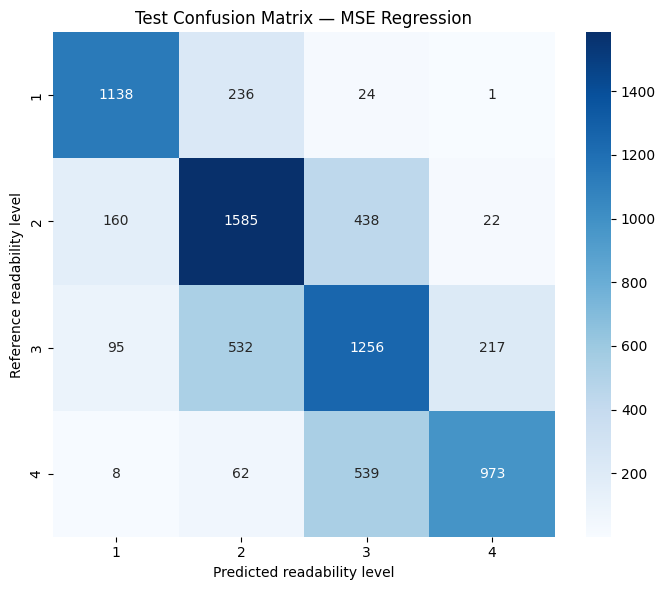

              precision    recall  f1-score   support

     Level 1     0.8123    0.8134    0.8129      1399
     Level 2     0.6563    0.7188    0.6861      2205
     Level 3     0.5565    0.5981    0.5765      2100
     Level 4     0.8021    0.6150    0.6962      1582

    accuracy                         0.6797      7286
   macro avg     0.7068    0.6863    0.6929      7286
weighted avg     0.6892    0.6797    0.6811      7286



In [27]:
human_labels = np.arange(1, NUM_LABELS + 1)
cm = confusion_matrix(test_labels + 1, test_predictions + 1, labels=human_labels)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=human_labels,
    yticklabels=human_labels,
)
plt.title(f"Test Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted readability level")
plt.ylabel("Reference readability level")
plt.tight_layout()
plt.show()

print(classification_report(
    test_labels + 1,
    test_predictions + 1,
    labels=human_labels,
    target_names=[f"Level {level}" for level in human_labels],
    digits=4,
    zero_division=0,
))


## 11. Save the selected model and experiment metadata

The tokenizer, selected weights, validation table, test metrics, and experimental constants are stored together. Custom CORAL weights are saved as a PyTorch state dictionary because its head is not a standard Hugging Face sequence-classification head.


In [28]:
SAVE_DIR = "./best_barec_readability_model"
os.makedirs(SAVE_DIR, exist_ok=True)
tokenizer.save_pretrained(SAVE_DIR)

if best_model_name == "CORAL":
    torch.save(best_trainer.model.state_dict(), os.path.join(SAVE_DIR, "coral_model_state.pt"))
    saved_format = "AraBERTCoral state_dict"
else:
    best_trainer.model.save_pretrained(SAVE_DIR)
    saved_format = "Hugging Face save_pretrained"

def json_safe(value):
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {key: json_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [json_safe(item) for item in value]
    return value

metadata = {
    "selected_model": best_model_name,
    "selection_metric": "validation_qwk",
    "checkpoint": MODEL_NAME,
    "saved_format": saved_format,
    "label_mapping": {"0": 1, "1": 2, "2": 3, "3": 4},
    "parameters": {
        "max_length": MAX_LENGTH,
        "seed": SEED,
        "learning_rate": LEARNING_RATE,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "effective_train_batch_size": TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
        "epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "warmup_fraction": WARMUP_FRACTION,
    },
    "validation_comparison": validation_comparison.to_dict(orient="records"),
    "test_metrics": test_metrics,
}

with open(os.path.join(SAVE_DIR, "experiment_metadata.json"), "w", encoding="utf-8") as file:
    json.dump(json_safe(metadata), file, ensure_ascii=False, indent=2)

print("Saved to:", SAVE_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./best_barec_readability_model


# Findings reporting template

Report the validation comparison first and identify the selected model solely by the highest validation QWK. Then report its test Accuracy, Macro-F1, QWK, MAE, RMSE, and within-one accuracy. Discuss whether most errors are adjacent levels using the confusion matrix. Do not claim superiority over published BAREC systems unless the corpus version, label scheme, preprocessing, split protocol, and evaluation metric are identical.

If the result is lower than published BAREC results, plausible experimental differences include the four-class label merge, the selected AraBERTv0.2 checkpoint, weighted rather than unweighted cross-entropy, sequence truncation, hyperparameter budget, and differences between this objective and a paper's complete training pipeline. These are methodological differences, not evidence that the implementation failed.


# References

[1] Antoun, W., Baly, F., & Hajj, H. (2020). **AraBERT: Transformer-based Model for Arabic Language Understanding.** OSACT 2020. https://aclanthology.org/2020.osact-1.2/

[2] Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). **BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.** NAACL-HLT 2019. https://aclanthology.org/N19-1423/

[3] Elmadani, K. N., Alhafni, B., Taha, H., & Habash, N. (2025). **BAREC Shared Task 2025 on Arabic Readability Assessment.** ArabicNLP 2025. https://aclanthology.org/2025.arabicnlp-sharedtasks.34/

[4] Cao, W., Mirjalili, V., & Raschka, S. (2020). **Rank-consistent Ordinal Regression for Neural Networks with Application to Age Estimation.** Pattern Recognition Letters, 140, 325–331. https://doi.org/10.1016/j.patrec.2020.11.008

[5] Elmadani, K. N., Habash, N., & Taha-Thomure, H. (2025). **A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.** Findings of ACL 2025. https://aclanthology.org/2025.findings-acl.842/

[6] Nazzal, A. M. (2025). **ZAI at BAREC Shared Task 2025: AraBERT CORAL for Fine Grained Arabic Readability.** ArabicNLP 2025 Shared Tasks. https://aclanthology.org/2025.arabicnlp-sharedtasks.37/

[7] Trigui, S. (2025). **STBW at BAREC Shared Task 2025: AraBERT-v2 with MSE-SoftQWK Loss for Sentence-Level Arabic Readability.** ArabicNLP 2025 Shared Tasks. https://aclanthology.org/2025.arabicnlp-sharedtasks.50/
